In [ ]:
!python --version


Python 3.12.12


In [ ]:
# 1️⃣ Install dependencies
!apt-get update
!apt-get install -y build-essential cmake git libgtk2.0-dev pkg-config libavcodec-dev libavformat-dev libswscale-dev

# 2️⃣ Clone Detectron2 repo
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2

# 3️⃣ Install Detectron2 from source
!python -m pip install -e .


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,328 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,887 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restrict

In [ ]:
# ================================
# 1️⃣ Mount Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to your filtered dataset
DATASET_ROOT = "/content/drive/MyDrive/DataSet-COCO-Final"
TRAIN_JSON = f"{DATASET_ROOT}/train/_annotations.coco.json"
TRAIN_IMG  = f"{DATASET_ROOT}/train/images"
VAL_JSON   = f"{DATASET_ROOT}/val/_annotations.coco.json"  # optional val set
VAL_IMG    = f"{DATASET_ROOT}/val/images"


In [ ]:
# Folder to save checkpoints & final model
CHECKPOINT_DIR = "/content/drive/MyDrive/MaskRCNN-SEG"
import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


In [ ]:
# Install dependencies
!apt-get update
!apt-get install -y build-essential cmake git libgtk2.0-dev pkg-config libavcodec-dev libavformat-dev libswscale-dev

# Clone repo (or update if already cloned)
!rm -rf detectron2
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2

# Build and install
!python -m pip install -e .


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
import detectron2
from detectron2.utils.logger import setup_logger

setup_logger()
print("✅ Detectron2 is installed and ready!")


✅ Detectron2 is installed and ready!


In [ ]:
# ================================
# 5️⃣ Imports
# ================================
import random
import cv2
import matplotlib.pyplot as plt
import torch

from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer
from detectron2 import model_zoo


In [ ]:
# ================================
# 6️⃣ Register COCO datasets
# ================================
register_coco_instances("pak_food_train", {}, TRAIN_JSON, TRAIN_IMG)
register_coco_instances("pak_food_val", {}, VAL_JSON, VAL_IMG)

metadata = MetadataCatalog.get("pak_food_train")
dataset_dicts = DatasetCatalog.get("pak_food_train")


[02/01 08:35:36 d2.data.datasets.coco]: Loading /content/drive/MyDrive/DataSet-COCO-Final/train/_annotations.coco.json takes 1.02 seconds.
WARNING [02/01 08:35:36 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[02/01 08:35:36 d2.data.datasets.coco]: Loaded 5370 images in COCO format from /content/drive/MyDrive/DataSet-COCO-Final/train/_annotations.coco.json


In [ ]:
# ================================
# 7️⃣ Optional: Visualize random samples
# ================================
def visualize_random_samples(n=3):
    for d in random.sample(dataset_dicts, n):
        img = cv2.imread(d["file_name"])
        v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=1.0)
        out = v.draw_dataset_dict(d)
        plt.figure(figsize=(10,10))
        plt.imshow(out.get_image())
        plt.axis("off")
        plt.show()

# visualize_random_samples(3)


In [ ]:
# ================================
# 8️⃣ Setup Detectron2 config
# ================================
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
))

cfg.DATASETS.TRAIN = ("pak_food_train",)
cfg.DATASETS.TEST  = ("pak_food_val",)

cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 5000  # adjust later for full dataset
cfg.SOLVER.STEPS = []

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 11  # your 11 classes
cfg.MODEL.DEVICE = "cuda"
cfg.OUTPUT_DIR = CHECKPOINT_DIR
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


In [ ]:

# ================================
# 9️⃣ Trainer with resume capability
# ================================
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)


[01/30 12:31:26 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:01, 145MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


In [ ]:

# ================================
# 🔹 Start training
# ================================
trainer.train()

[01/30 12:32:33 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0130 12:32:36.590000 1029 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[01/30 12:32:52 d2.utils.events]:  eta: 1:09:17  iter: 19  total_loss: 3.74  loss_cls: 2.415  loss_box_reg: 0.622  loss_mask: 0.6934  loss_rpn_cls: 0.008841  loss_rpn_loc: 0.007648    time: 0.8253  last_time: 0.7979  data_time: 0.5207  last_data_time: 0.5139   lr: 4.9953e-06  max_mem: 1772M
[01/30 12:33:16 d2.utils.events]:  eta: 1:11:02  iter: 39  total_loss: 3.427  loss_cls: 2.266  loss_box_reg: 0.4977  loss_mask: 0.691  loss_rpn_cls: 0.01175  loss_rpn_loc: 0.005885    time: 0.8243  last_time: 0.8639  data_time: 0.5127  last_data_time: 0.5675   lr: 9.9902e-06  max_mem: 1806M
[01/30 12:33:33 d2.utils.events]:  eta: 1:10:45  iter: 59  total_loss: 3.191  loss_cls: 1.977  loss_box_reg: 0.5516  loss_mask: 0.6879  loss_rpn_cls: 0.01585  loss_rpn_loc: 0.008768    time: 0.8403  last_time: 1.3398  data_time: 0.5592  last_data_time: 1.0209   lr: 1.4985e-05  max_mem: 1806M
[01/30 12:33:50 d2.utils.events]:  eta: 1:10:37  iter: 79  total_loss: 2.8  loss_cls: 1.58  loss_box_reg: 0.5257  loss_mask

[01/30 13:30:17 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/MaskRCNN-SEG/model_final.pth ...


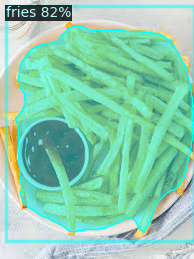

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

# Load config and weights
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/MaskRCNN-SEG/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Confidence threshold
predictor = DefaultPredictor(cfg)

# Load an image
im = cv2.imread("/content/drive/MyDrive/TEST_IMAGE_17.jpeg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


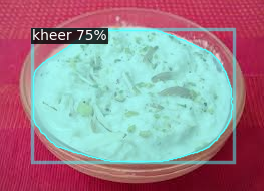

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/TEST_IMAGE_11.jpeg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


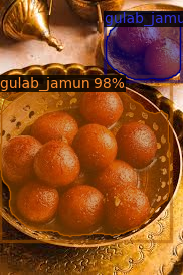

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/TEST_IMAGE_10.jpeg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


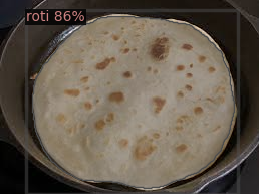

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/TEST_IMAGE_9.jpeg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


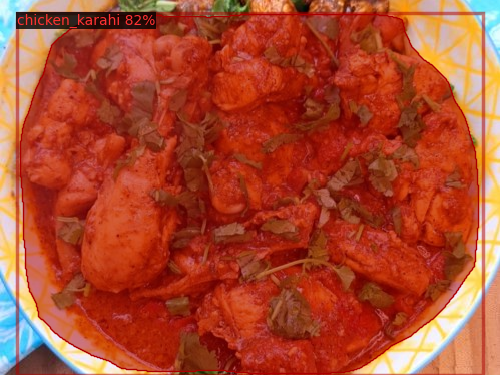

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/TEST_IMAGE_4.jpg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


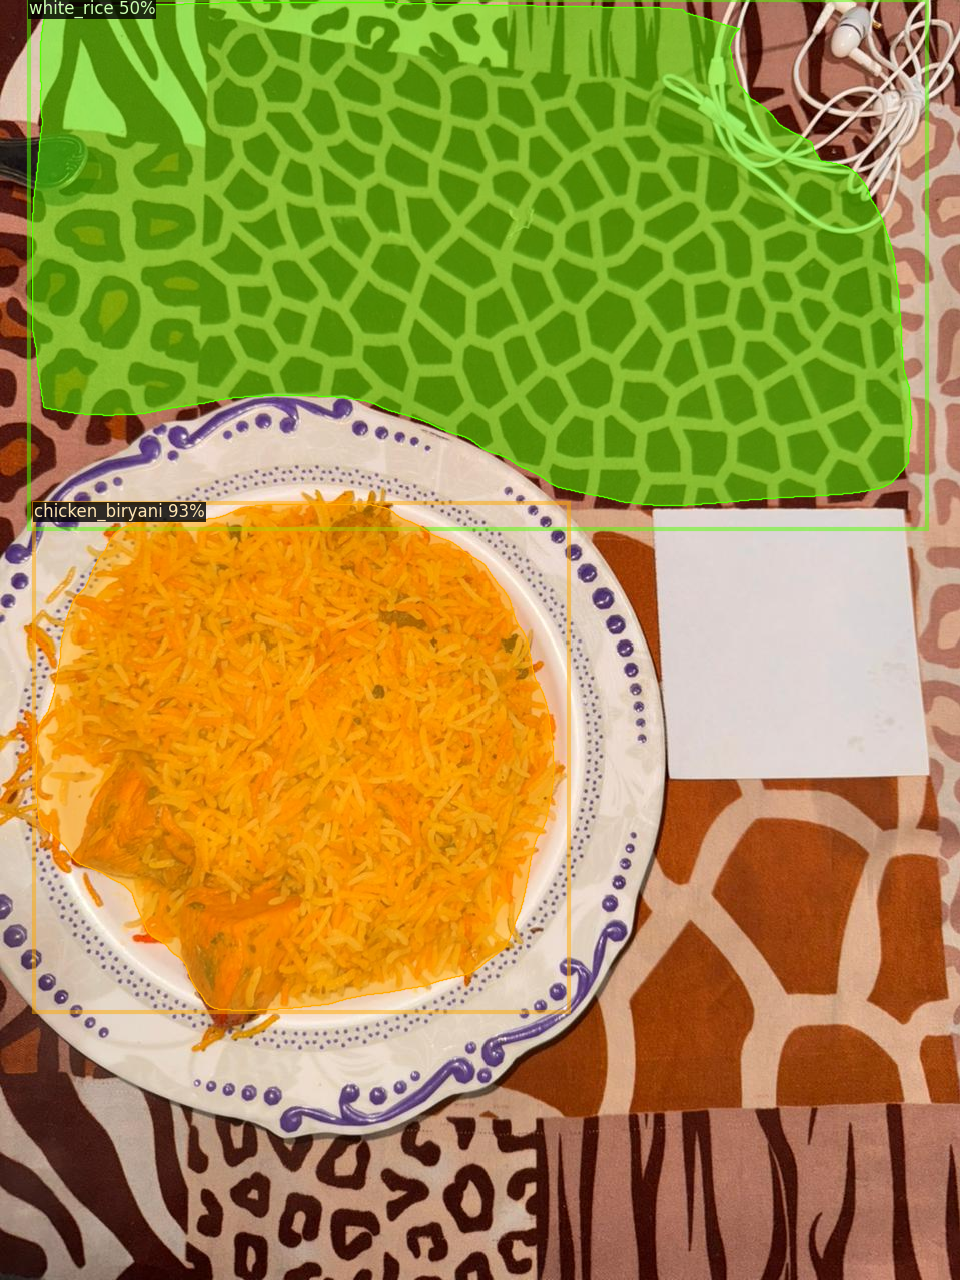

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/IMG-20251124-WA0036.jpg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[02/01 08:36:01 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/MaskRCNN-SEG/model_final.pth ...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0201 08:36:11.053000 681 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


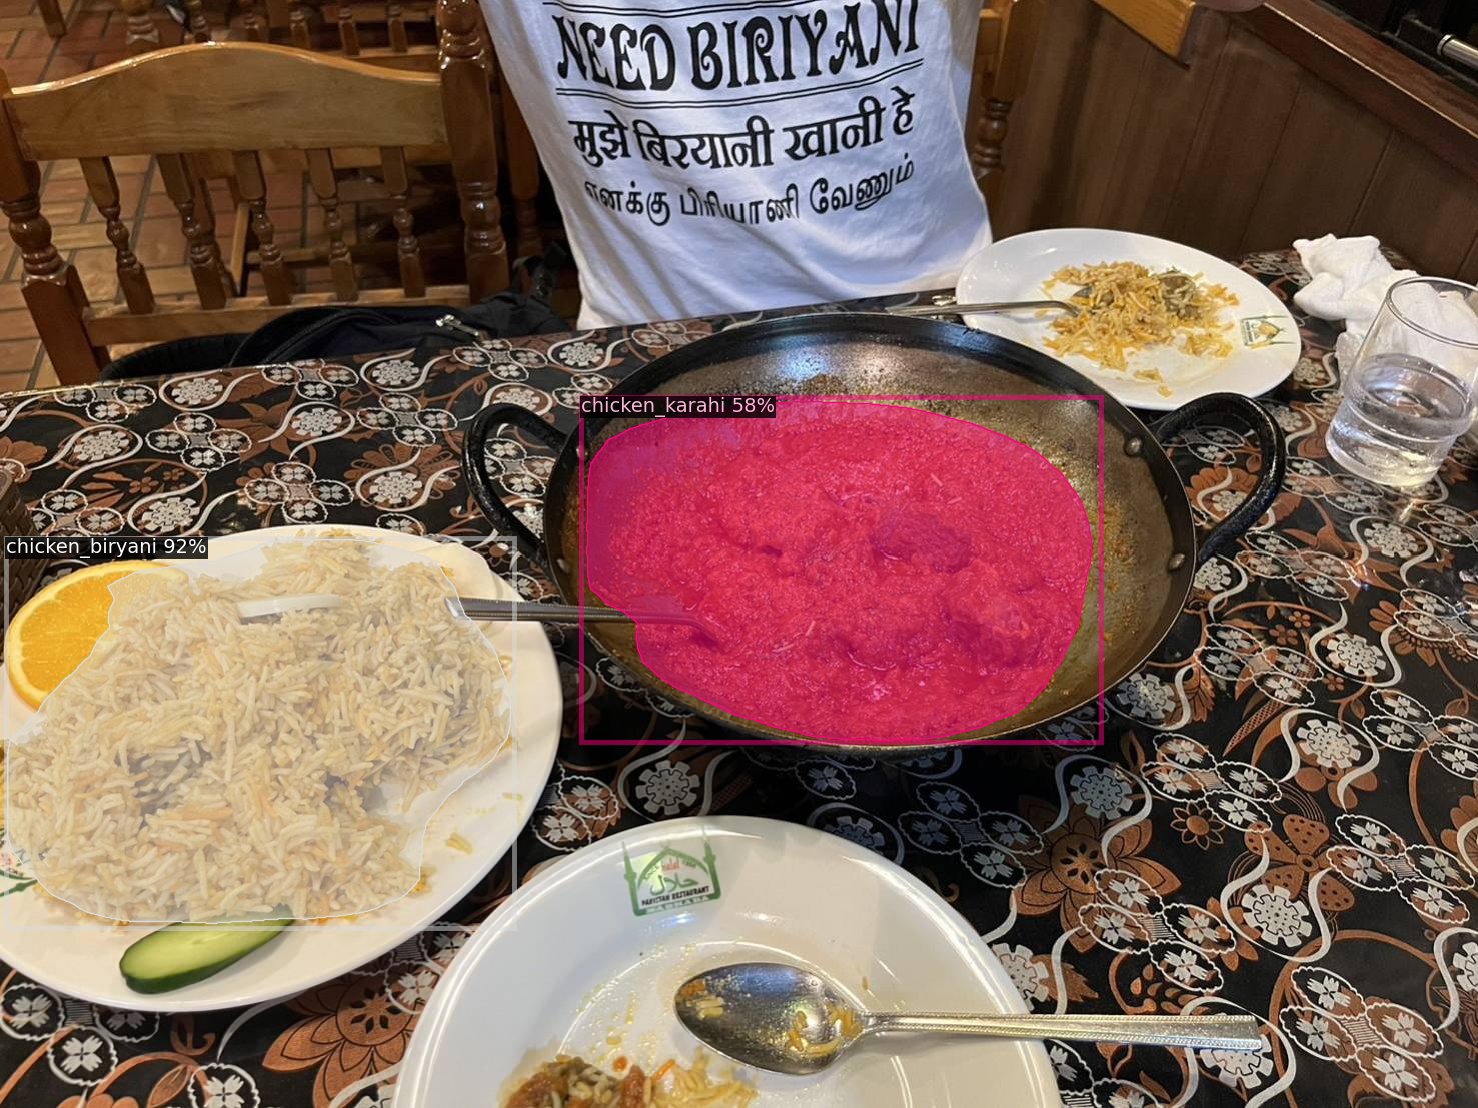

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
from google.colab import drive
drive.mount('/content/drive')
# Load config and weights
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/MaskRCNN-SEG/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Confidence threshold
predictor = DefaultPredictor(cfg)

# Load an image
im = cv2.imread("/content/drive/MyDrive/seg-test-2.jpg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])


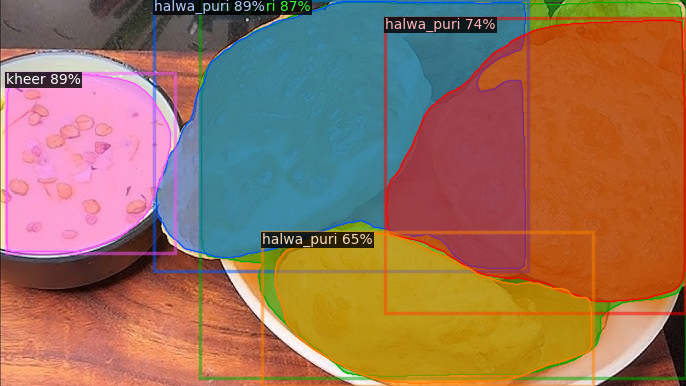

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/seg-test-3.jpg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])

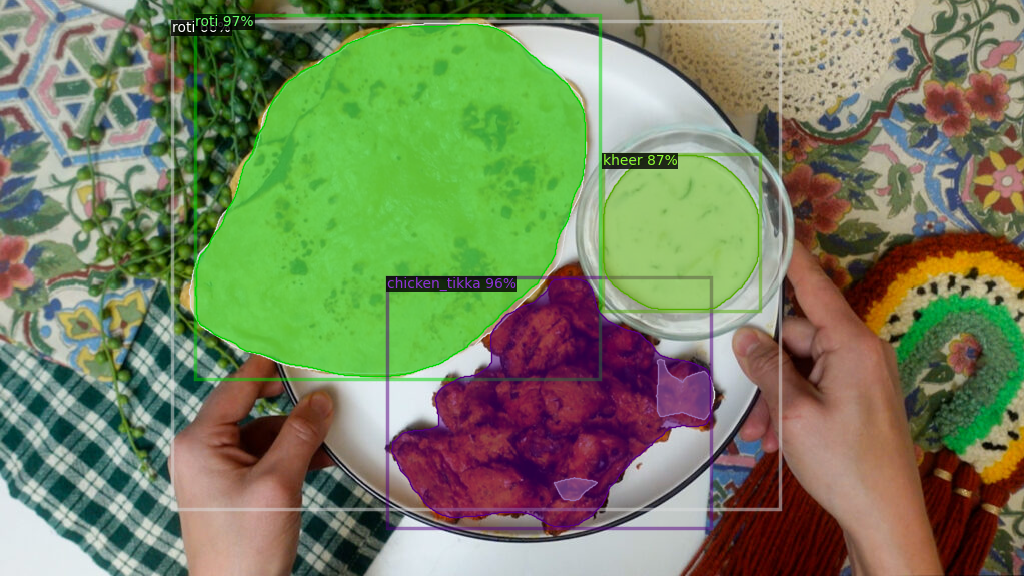

In [ ]:

# Load an image
im = cv2.imread("/content/drive/MyDrive/seg-test-4.jpg")

# Make prediction
outputs = predictor(im)

# Visualize prediction
metadata = MetadataCatalog.get("pak_food_train")
v = Visualizer(im[:, :, ::-1], metadata=metadata, scale=1.0, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show image in Colab
cv2_imshow(out.get_image()[:, :, ::-1])